In [395]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns",None)

In [396]:
df = pd.read_excel("premiums.xlsx")

df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


In [397]:
df.shape

(50000, 13)

In [398]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Age                    50000 non-null  int64 
 1   Gender                 50000 non-null  object
 2   Region                 50000 non-null  object
 3   Marital_status         50000 non-null  object
 4   Number Of Dependants   50000 non-null  int64 
 5   BMI_Category           50000 non-null  object
 6   Smoking_Status         49989 non-null  object
 7   Employment_Status      49998 non-null  object
 8   Income_Level           49987 non-null  object
 9   Income_Lakhs           50000 non-null  int64 
 10  Medical History        50000 non-null  object
 11  Insurance_Plan         50000 non-null  object
 12  Annual_Premium_Amount  50000 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 5.0+ MB


In [399]:
df.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.593480,1.712080,23.018200,15768.116320
std,15.000437,1.498248,24.219197,8419.839675
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13929.000000
75%,45.000000,3.000000,31.000000,22275.250000
max,356.000000,5.000000,930.000000,43471.000000


In [400]:
df.sample(5)

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
24754,30,Female,Southeast,Married,4,Obesity,No Smoking,Salaried,<10L,5,Diabetes & Thyroid,Bronze,14668
20178,21,Female,Northeast,Unmarried,1,Normal,No Smoking,Freelancer,10L - 25L,24,No Disease,Silver,9207
17628,36,Male,Southeast,Married,3,Normal,No Smoking,Salaried,25L - 40L,30,Diabetes & High blood pressure,Silver,17913
36601,34,Male,Southwest,Unmarried,0,Normal,Regular,Salaried,<10L,7,High blood pressure,Bronze,12308
26336,33,Female,Northwest,Married,3,Obesity,No Smoking,Salaried,<10L,8,Thyroid,Bronze,13480


In [401]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [402]:
# Standardize Column Names
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ","_")
)

In [403]:
# Missing Values
df.isnull().sum()
(df.isnull().sum()/len(df))*100

,0
age,0.000
gender,0.000
region,0.000
marital_status,0.000
number_of_dependants,0.000
bmi_category,0.000
smoking_status,0.022
employment_status,0.004
income_level,0.026
income_lakhs,0.000


In [404]:
df.dropna(inplace=True)

In [405]:
df.isnull().sum()

,0
age,0
gender,0
region,0
marital_status,0
number_of_dependants,0
bmi_category,0
smoking_status,0
employment_status,0
income_level,0
income_lakhs,0


In [406]:
df.duplicated().sum()

np.int64(0)

In [407]:
df.drop_duplicates(inplace=True)

In [408]:
df.duplicated().sum()

np.int64(0)

In [409]:
df.describe().T
# Look for

# negative values
# unrealistic age
# outliers

,count,mean,std,min,25%,50%,75%,max
age,49976.0,34.591764,15.000378,18.0,22.00,31.0,45.0,356.0
number_of_dependants,49976.0,1.711842,1.498195,-3.0,0.00,2.0,3.0,5.0
income_lakhs,49976.0,23.021150,24.221794,1.0,7.00,17.0,31.0,930.0
annual_premium_amount,49976.0,15766.810189,8419.995271,3501.0,8607.75,13928.0,22273.5,43471.0


In [410]:
# Fix Negative Dependants
# Check if any negative values exist
df[df["number_of_dependants"] < 0]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
402,23,Female,Southwest,Unmarried,-3,Underweight,No Smoking,Freelancer,10L - 25L,18,No Disease,Silver,9309
2245,18,Male,Southwest,Unmarried,-3,Overweight,No Smoking,Freelancer,25L - 40L,28,No Disease,Silver,8095
2323,19,Male,Northwest,Unmarried,-3,Underweight,No Smoking,Freelancer,25L - 40L,40,No Disease,Bronze,4641
2986,34,Female,Southeast,Married,-1,Underweight,Regular,Self-Employed,25L - 40L,35,High blood pressure & Heart disease,Silver,22995
3756,41,Male,Southwest,Married,-1,Obesity,Regular,Salaried,10L - 25L,21,Diabetes,Silver,22766
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48062,23,Male,Northwest,Unmarried,-1,Normal,No Smoking,Freelancer,> 40L,54,No Disease,Gold,13601
48086,36,Female,Southwest,Married,-1,Obesity,Occasional,Salaried,<10L,3,Diabetes,Bronze,14422
49256,60,Female,Southwest,Married,-1,Normal,No Smoking,Self-Employed,10L - 25L,21,Thyroid,Bronze,10141
49270,34,Male,Southeast,Married,-1,Obesity,No Smoking,Self-Employed,10L - 25L,17,Diabetes & Thyroid,Silver,21816


In [411]:
df["number_of_dependants"] = df["number_of_dependants"].abs()

In [412]:
# Detect Outliers

numeric_cols = df.select_dtypes(include="number").columns

numeric_cols

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

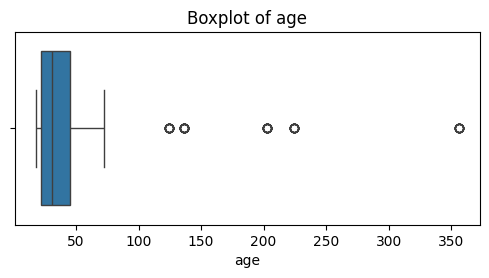

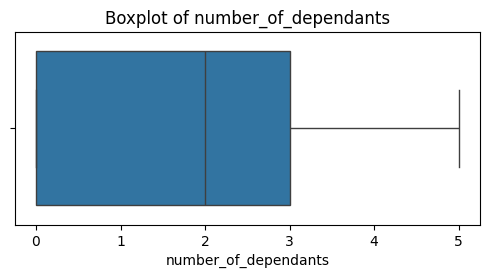

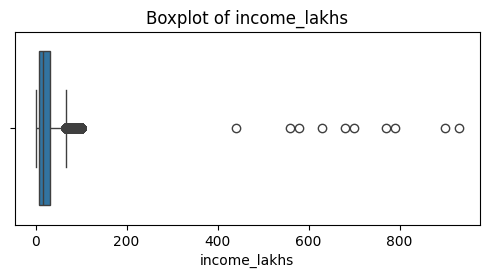

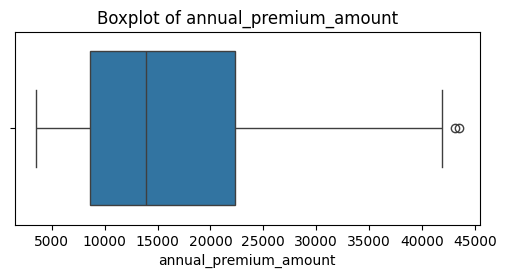

In [413]:
# Draw Boxplots
import matplotlib.pyplot as plt
import seaborn as sns

for col in numeric_cols:

    plt.figure(figsize=(6,2.5))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

In [414]:
# Remove Unrealistic Age
# Check maximum age first.

df["age"].describe()

,age
count,49976.000000
mean,34.591764
std,15.000378
min,18.000000
25%,22.000000
50%,31.000000
75%,45.000000
max,356.000000


In [415]:
# Remove ages greater than 100.

df = df[df["age"] <= 100].copy()

In [416]:
df["age"].describe()

,age
count,49918.000000
mean,34.401839
std,13.681600
min,18.000000
25%,22.000000
50%,31.000000
75%,45.000000
max,72.000000


In [417]:
# Remove Income Outliers
# IQR Function
def get_iqr_bounds(column):

    q1 = column.quantile(0.25)
    q3 = column.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return lower, upper

In [418]:
# Calculate Bounds
lower, upper = get_iqr_bounds(df["income_lakhs"])

print("lower bound :", lower)
print("upper bound :", upper)

lower bound : -29.0
upper bound : 67.0


In [419]:
# Use 99.9 Percentile (as in the project)
threshold = df["income_lakhs"].quantile(0.999)

print(threshold)

100.0


In [420]:
# Remove Extreme Income Values
df = df[df["income_lakhs"] <= threshold].copy()

In [421]:
df["income_lakhs"].describe()

,income_lakhs
count,49908.000000
mean,22.889897
std,22.170699
min,1.000000
25%,7.000000
50%,17.000000
75%,31.000000
max,100.000000


In [422]:
df.shape

(49908, 13)

In [423]:
df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


# EDA

In [424]:
# Numerical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

print(num_cols)

['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount']


In [425]:
# Categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(cat_cols)

['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status', 'income_level', 'medical_history', 'insurance_plan']


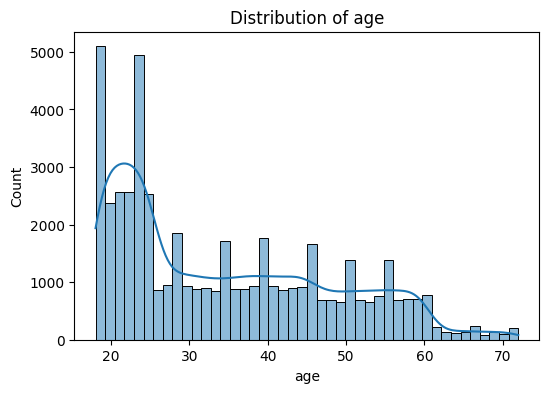

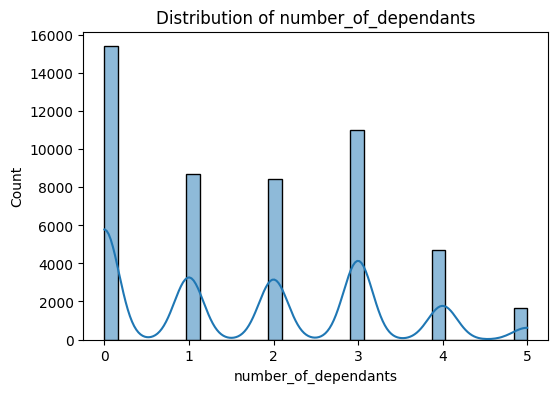

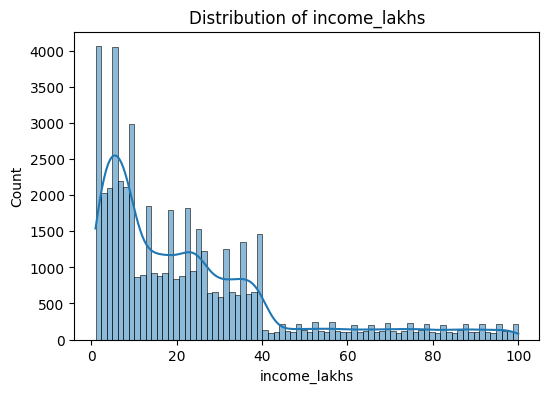

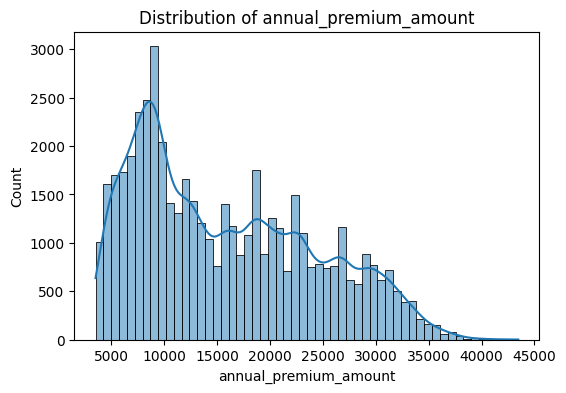

In [426]:
# Univariate Analysis (Numerical)

import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True)

    plt.title(f'Distribution of {col}')

    plt.show()

In [427]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,49908.0,34.401579,13.681604,18.0,22.0,31.0,45.0,72.0
number_of_dependants,49908.0,1.717640,1.492032,0.0,0.0,2.0,3.0,5.0
income_lakhs,49908.0,22.889897,22.170699,1.0,7.0,17.0,31.0,100.0
annual_premium_amount,49908.0,15765.739641,8418.674061,3501.0,8608.0,13928.0,22270.5,43471.0


In [428]:
# Skewness
df[num_cols].skew()

,0
age,0.627236
number_of_dependants,0.341837
income_lakhs,1.588071
annual_premium_amount,0.518268


In [429]:
# Bivariate Analysis (Numerical vs Target)

target = "annual_premium_amount"

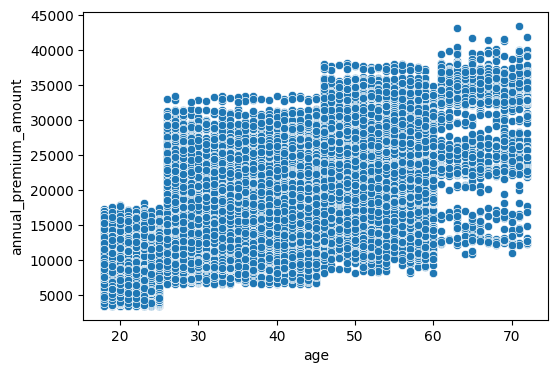

In [430]:
# Age vs Premium
plt.figure(figsize=(6,4))

sns.scatterplot(data=df,
                x="age",
                y=target)

plt.show()

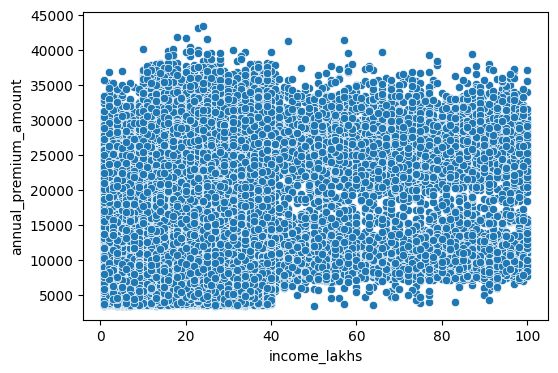

In [431]:
# Income vs Premium
plt.figure(figsize=(6,4))

sns.scatterplot(data=df,
                x="income_lakhs",
                y=target)

plt.show()

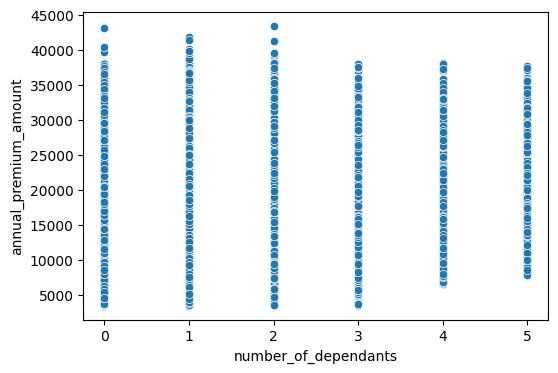

In [432]:
# Dependants vs Premium
plt.figure(figsize=(6,4))

sns.scatterplot(data=df,
                x="number_of_dependants",
                y=target)

plt.show()

In [433]:
# Correlation Matrix
corr = df[num_cols].corr()

corr

,age,number_of_dependants,income_lakhs,annual_premium_amount
age,1.000000,0.415742,0.025060,0.767569
number_of_dependants,0.415742,1.000000,0.006074,0.414691
income_lakhs,0.025060,0.006074,1.000000,0.243058
annual_premium_amount,0.767569,0.414691,0.243058,1.000000


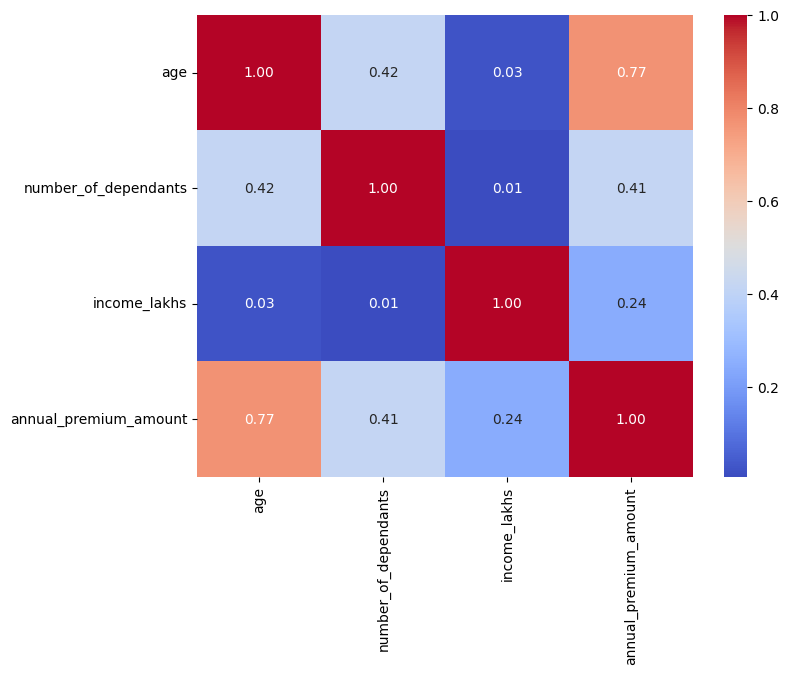

In [434]:
# Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.show()

In [435]:
# Explore Categorical Columns
for col in cat_cols:

    print(f"\n{col}")

    print(df[col].unique())


gender
['Male' 'Female']

region
['Northwest' 'Southeast' 'Northeast' 'Southwest']

marital_status
['Unmarried' 'Married']

bmi_category
['Normal' 'Obesity' 'Overweight' 'Underweight']

smoking_status
['No Smoking' 'Regular' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']

employment_status
['Salaried' 'Self-Employed' 'Freelancer']

income_level
['<10L' '10L - 25L' '> 40L' '25L - 40L']

medical_history
['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']

insurance_plan
['Bronze' 'Silver' 'Gold']


In [436]:
# Check Category Counts
for col in cat_cols:

    print(f"\n{col}")

    print(df[col].value_counts())


gender
gender
Male      27431
Female    22477
Name: count, dtype: int64

region
region
Southeast    17487
Southwest    15124
Northwest    10028
Northeast     7269
Name: count, dtype: int64

marital_status
marital_status
Unmarried    25630
Married      24278
Name: count, dtype: int64

bmi_category
bmi_category
Normal         23469
Overweight     11541
Underweight     7752
Obesity         7146
Name: count, dtype: int64

smoking_status
smoking_status
No Smoking        27321
Regular           15664
Occasional         6901
Smoking=0             8
Not Smoking           8
Does Not Smoke        6
Name: count, dtype: int64

employment_status
employment_status
Salaried         20932
Freelancer       15399
Self-Employed    13577
Name: count, dtype: int64

income_level
income_level
<10L         18643
10L - 25L    14369
25L - 40L    10273
> 40L         6623
Name: count, dtype: int64

medical_history
medical_history
No Disease                             21138
Diabetes                              

In [437]:
# Percentage Distribution
for col in cat_cols:

    print(f"\n{col}")

    print(round(df[col].value_counts(normalize=True)*100,2))


gender
gender
Male      54.96
Female    45.04
Name: proportion, dtype: float64

region
region
Southeast    35.04
Southwest    30.30
Northwest    20.09
Northeast    14.56
Name: proportion, dtype: float64

marital_status
marital_status
Unmarried    51.35
Married      48.65
Name: proportion, dtype: float64

bmi_category
bmi_category
Normal         47.02
Overweight     23.12
Underweight    15.53
Obesity        14.32
Name: proportion, dtype: float64

smoking_status
smoking_status
No Smoking        54.74
Regular           31.39
Occasional        13.83
Smoking=0          0.02
Not Smoking        0.02
Does Not Smoke     0.01
Name: proportion, dtype: float64

employment_status
employment_status
Salaried         41.94
Freelancer       30.85
Self-Employed    27.20
Name: proportion, dtype: float64

income_level
income_level
<10L         37.35
10L - 25L    28.79
25L - 40L    20.58
> 40L        13.27
Name: proportion, dtype: float64

medical_history
medical_history
No Disease                        

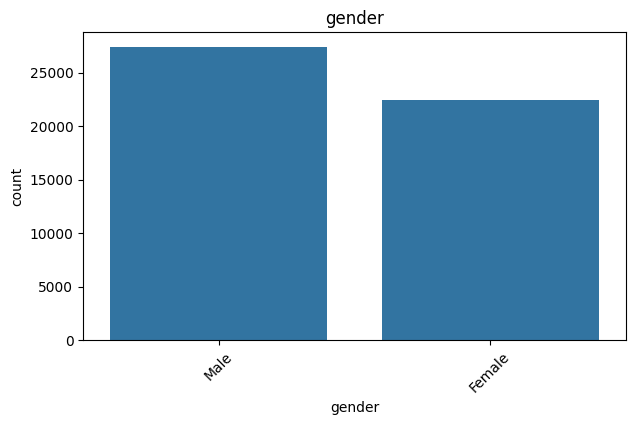

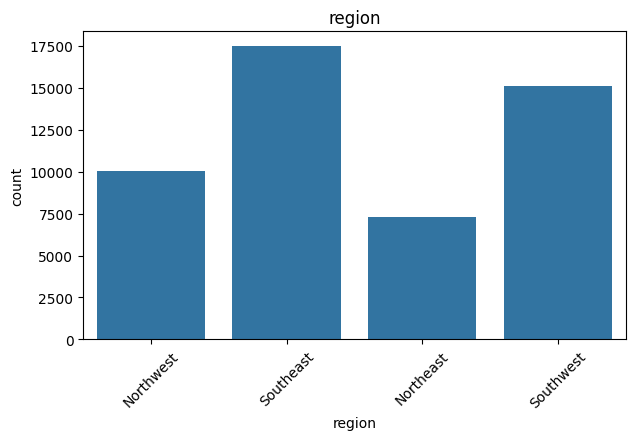

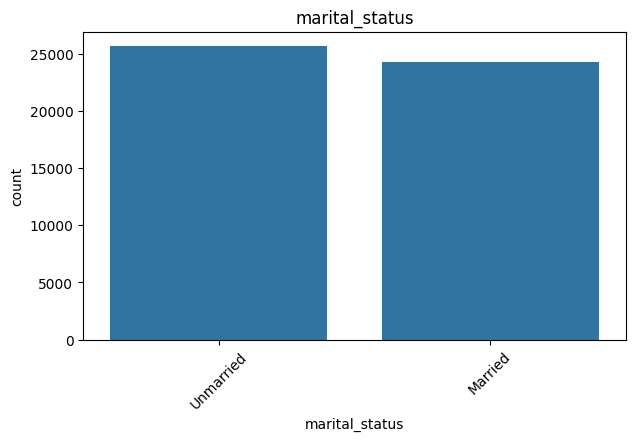

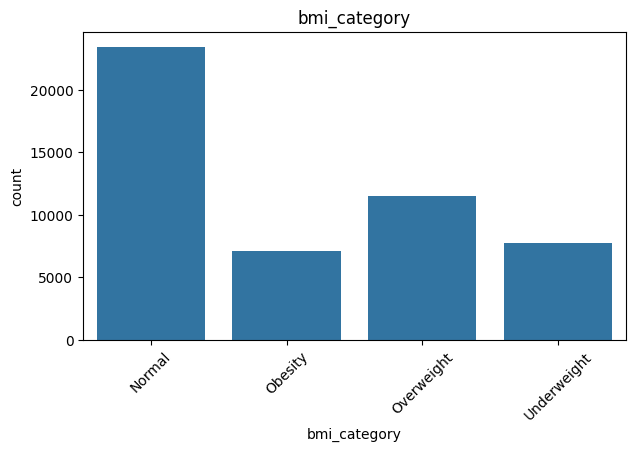

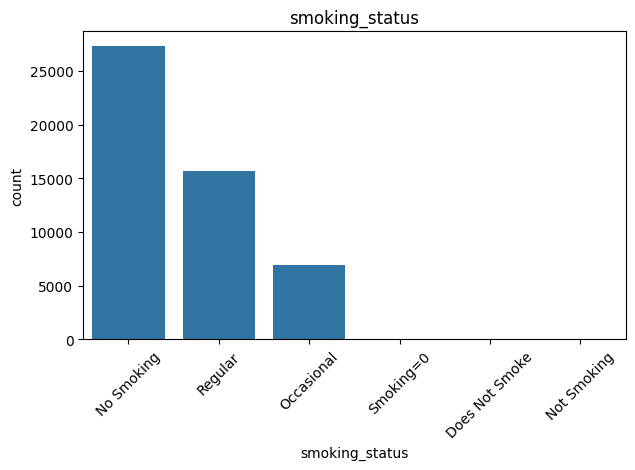

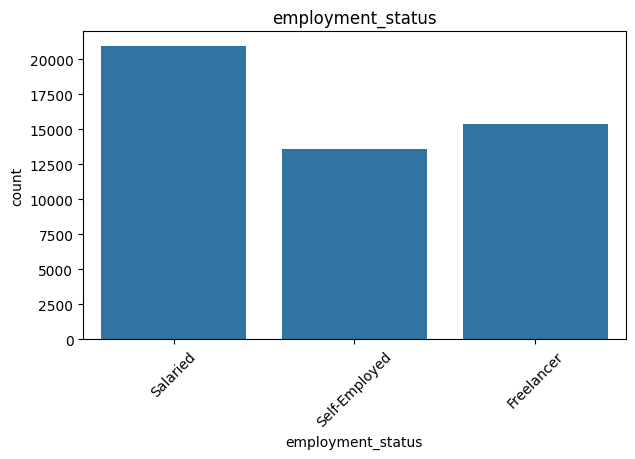

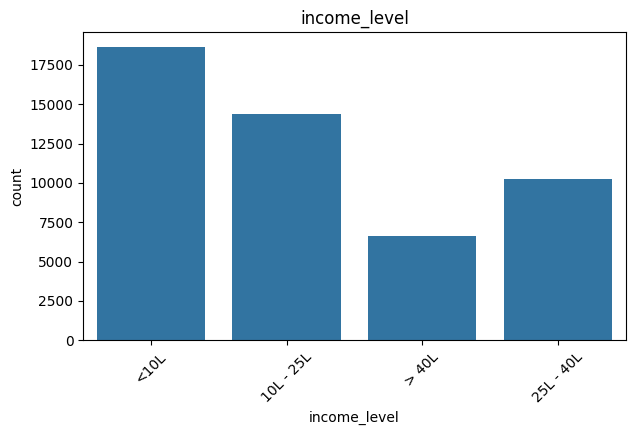

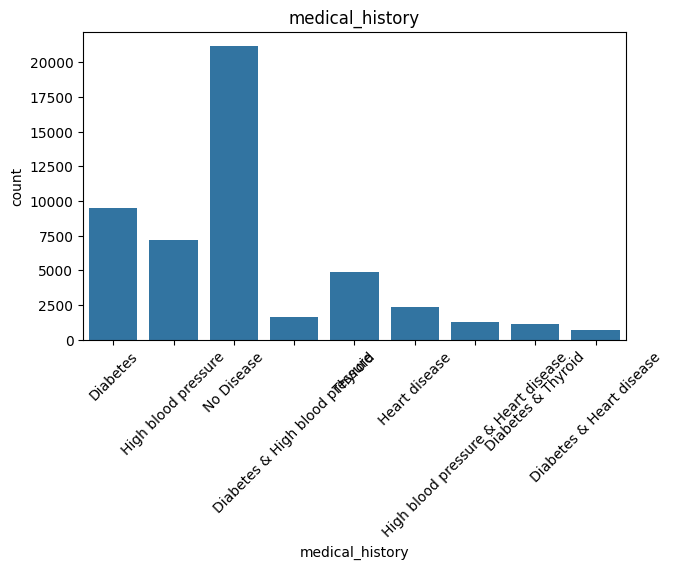

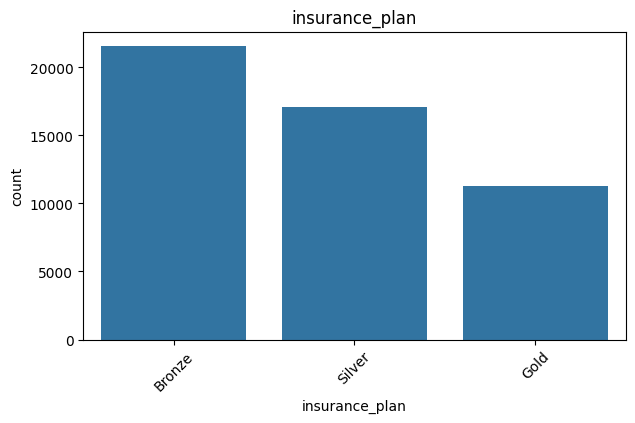

In [438]:
# Bar Charts
for col in cat_cols:

    plt.figure(figsize=(7,4))

    sns.countplot(data=df,
                  x=col)

    plt.xticks(rotation=45)

    plt.title(col)

    plt.show()

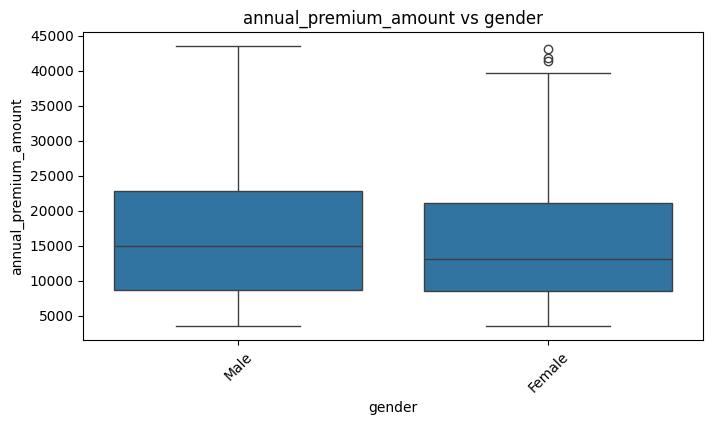

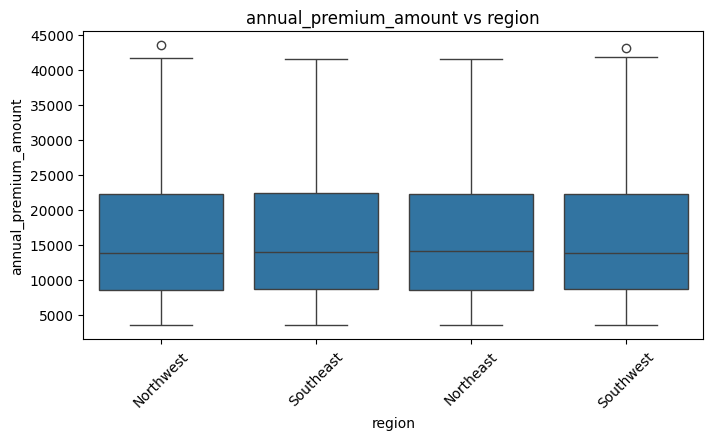

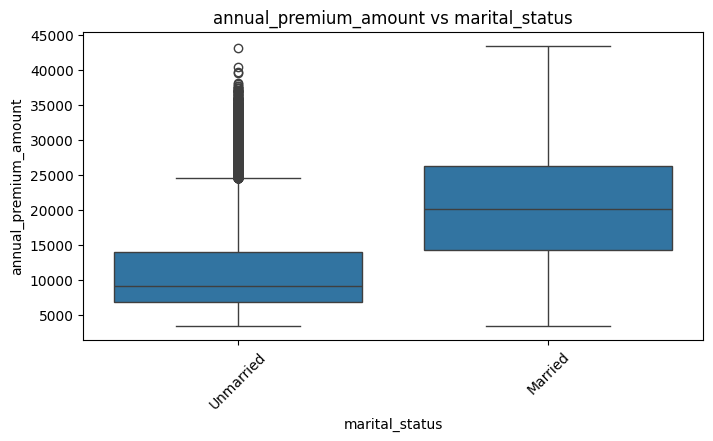

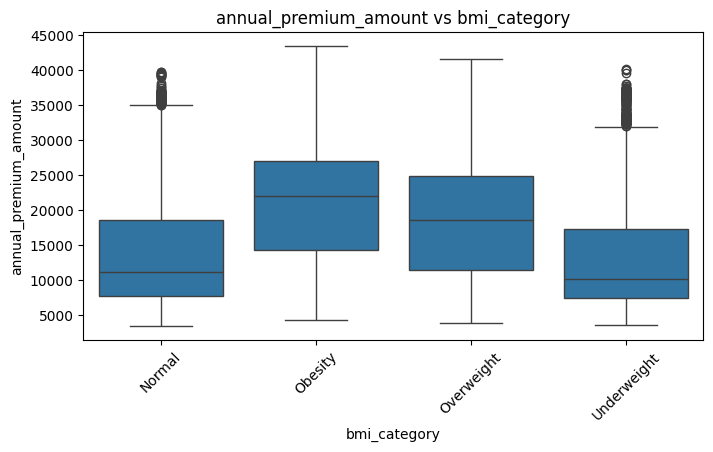

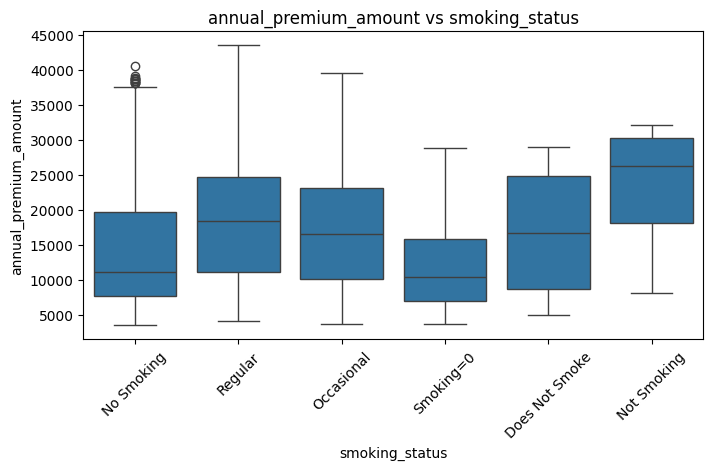

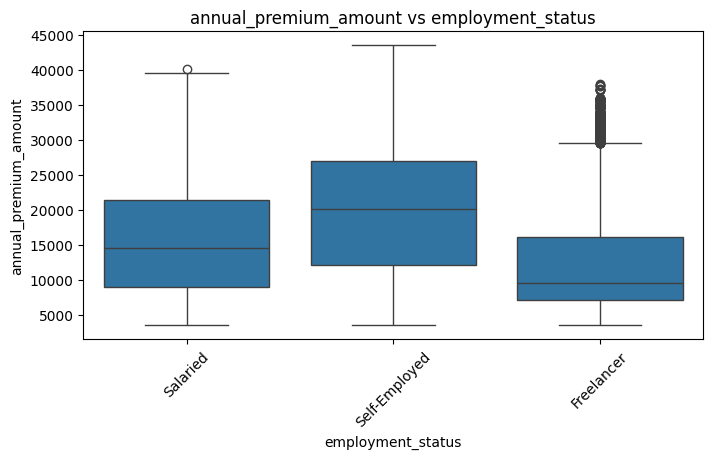

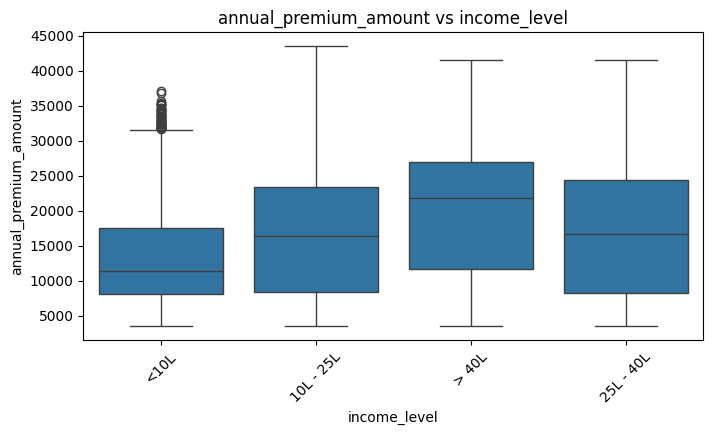

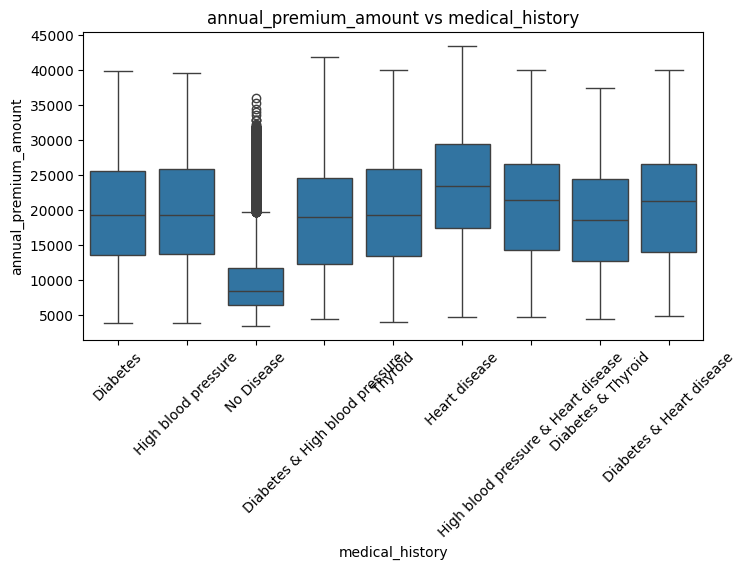

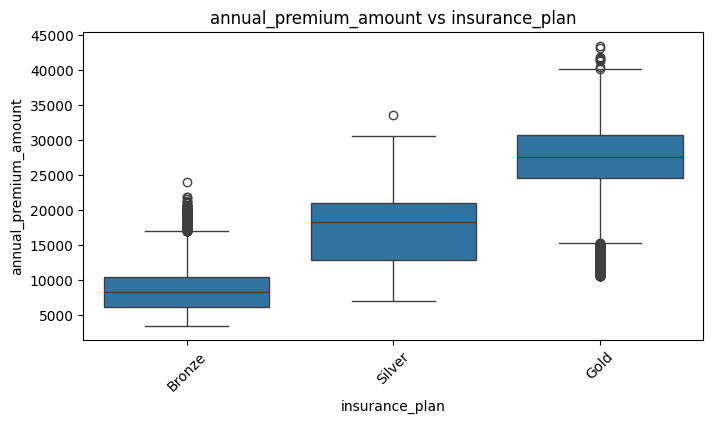

In [439]:
# Premium by Category (Boxplots)

for col in cat_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(data=df,
                x=col,
                y=target)

    plt.xticks(rotation=45)

    plt.title(f'{target} vs {col}')

    plt.show()

In [440]:
# Crosstab Analysis
# for example: Income Level vs Insurance Plan

cross = pd.crosstab(df["income_level"],
                    df["insurance_plan"])

cross

insurance_plan,Bronze,Gold,Silver
income_level,,,
10L - 25L,5307,3880,5182
25L - 40L,3683,2840,3750
<10L,12226,931,5486
> 40L,329,3653,2641


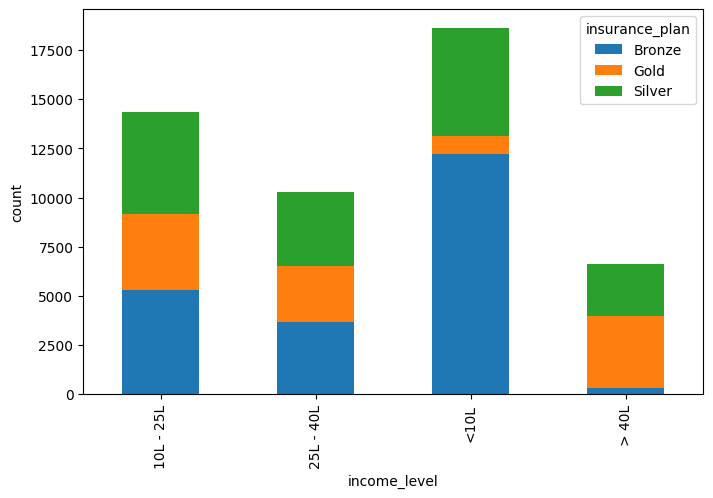

In [441]:
# Stacked Bar Chart
cross.plot(kind="bar",
           stacked=True,
           figsize=(8,5))

plt.ylabel("count")

plt.show()

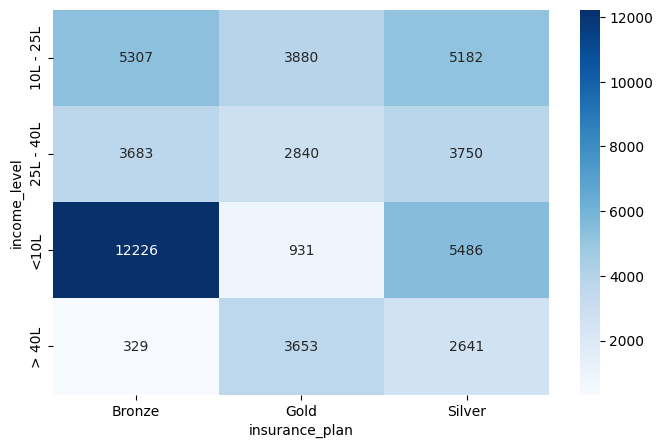

In [442]:
# Heatmap
plt.figure(figsize=(8,5))

sns.heatmap(cross,
            annot=True,
            cmap="Blues",
            fmt='d')

plt.show()

# Feature Engineering

In [443]:
# Create a Copy
df_fe = df.copy()

In [444]:
# Check Medical History Values
df_fe["medical_history"].unique()

array(['Diabetes', 'High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Thyroid', 'Heart disease',
       'High blood pressure & Heart disease', 'Diabetes & Thyroid',
       'Diabetes & Heart disease'], dtype=object)

In [445]:
df_fe["medical_history"].value_counts()

,count
medical_history,
No Disease,21138
Diabetes,9533
High blood pressure,7209
Thyroid,4917
Heart disease,2343
Diabetes & High blood pressure,1641
High blood pressure & Heart disease,1273
Diabetes & Thyroid,1115
Diabetes & Heart disease,739


In [446]:
#Create Health Risk Score

# In short: Create a dictionary for disease scores.

risk_score = {
    "No Disease": 0,
    "High blood pressure": 2,
    "Thyroid": 3,
    "Diabetes": 6,
    "Heart disease": 8,
    "Diabetes & High blood pressure": 8,
    "Diabetes & Thyroid": 9,
    "High blood pressure & Heart disease": 10,
    "Diabetes & Heart disease": 14
}

In [447]:
# Map Risk Score
df_fe["health_risk_score"] = df_fe["medical_history"].map(risk_score)

In [448]:
# Normalize Health Risk Score
from sklearn.preprocessing import MinMaxScaler

risk_scaler = MinMaxScaler()

df_fe["health_risk_score"] = risk_scaler.fit_transform(
    df_fe[["health_risk_score"]]
)

In [449]:
df_fe["health_risk_score"].describe()

,health_risk_score
count,49908.000000
mean,0.216613
std,0.242395
min,0.000000
25%,0.000000
50%,0.142857
75%,0.428571
max,1.000000


In [450]:
# Encode Insurance Plan (Ordinal)

df_fe["insurance_plan"].value_counts()

,count
insurance_plan,
Bronze,21545
Silver,17059
Gold,11304


In [451]:
plan_map = {
    "Bronze":1,
    "Silver":2,
    "Gold":3
}

df_fe["insurance_plan"] = df_fe["insurance_plan"].map(plan_map)

In [452]:
# Drop Medical History because we have already converted it into Health_Risk_Score.

df_fe = df_fe.drop(columns=["medical_history"])

In [453]:
# Now encode the remaining nominal categorical columns.

nominal_cols = [
    "Gender",
    "Region",
    "Marital_status",
    "BMI_Category",
    "Smoking_Status",
    "Employment_Status",
    "Income_Level"
]

In [454]:
df_fe.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,health_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,1,9053,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,1,16339,0.428571
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,2,18164,0.142857
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,3,20303,0.000000
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,2,13365,0.142857


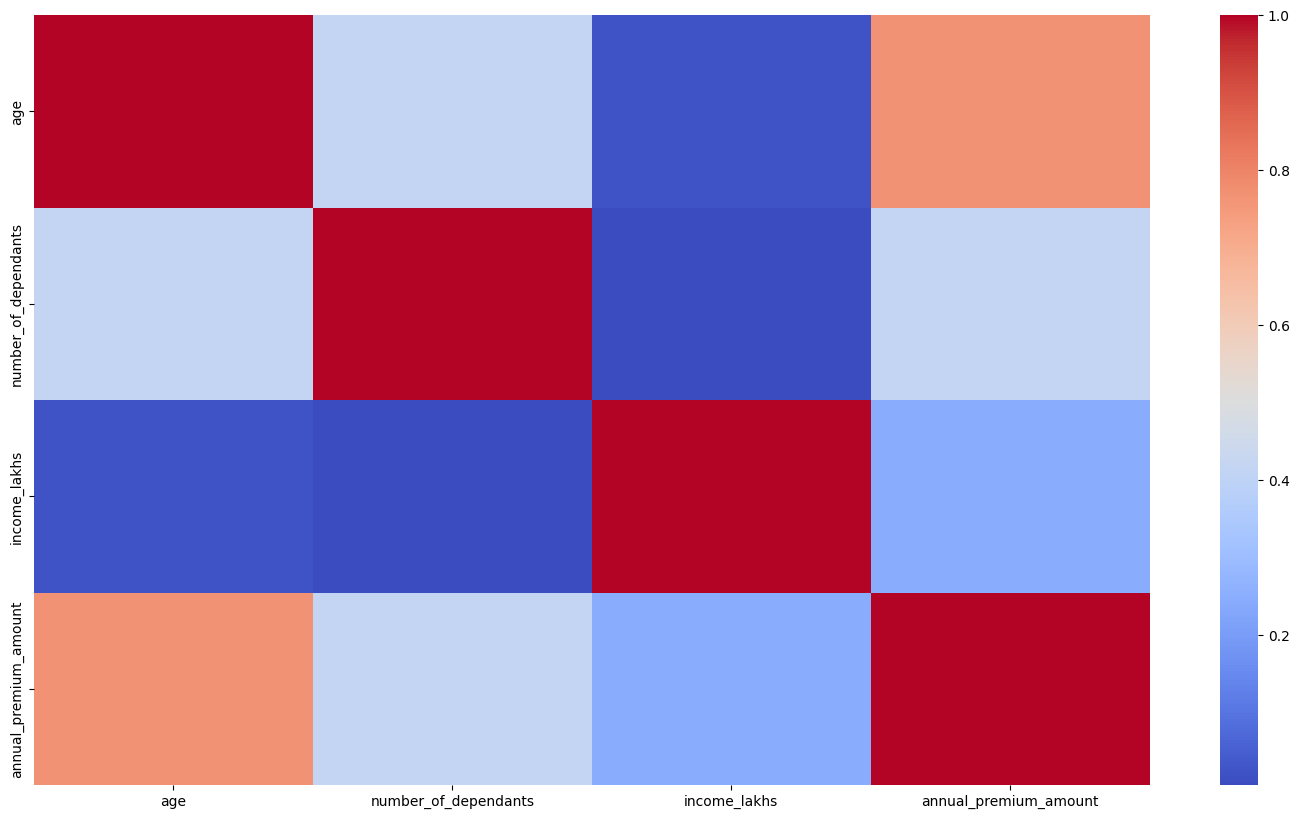

In [455]:
plt.figure(figsize=(18,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.show()

In [456]:
# Split X and y
X = df_fe.drop("annual_premium_amount", axis=1)

y = df_fe["annual_premium_amount"]

In [457]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

In [458]:
numeric_features = [
    "Age",
    "Number Of Dependants",
    "Income_Lakhs",
    "Health_Risk_Score"
]

# Model Comparison

In [459]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np
import pandas as pd

In [460]:
# Clean column names
X.columns = (
    X.columns.astype(str)
             .str.replace('[', '(', regex=False)
             .str.replace(']', ')', regex=False)
             .str.replace('<', '_less_', regex=False)
             .str.replace('>', '_greater_', regex=False)
             .str.replace(' ', '_', regex=False)
)

print(X.columns)

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'insurance_plan', 'health_risk_score'],
      dtype='object')


In [461]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [462]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [463]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(39926, 12)
(9982, 12)
(39926,)
(9982,)


In [464]:
X.dtypes

,0
age,int64
gender,object
region,object
marital_status,object
number_of_dependants,int64
bmi_category,object
smoking_status,object
employment_status,object
income_level,object
income_lakhs,int64


In [465]:
# Encode Categorical Columns
X = pd.get_dummies(
    df_fe.drop(columns=["annual_premium_amount"]),
    drop_first=True,
    dtype=int
)

y = df_fe["annual_premium_amount"]

In [466]:
X.select_dtypes(include="object").columns

Index([], dtype='object')

In [467]:
# Recreate X from feature-engineered dataframe
X = df_fe.drop(columns=["annual_premium_amount"]).copy()

# Convert ALL remaining object columns to dummy variables
X = pd.get_dummies(X, drop_first=True)

# Target
y = df_fe["annual_premium_amount"]

# Check that no object columns remain
print(X.select_dtypes(include="object").columns)

Index([], dtype='object')


In [468]:
print(X_train.dtypes[X_train.dtypes == "object"])

gender               object
region               object
marital_status       object
bmi_category         object
smoking_status       object
employment_status    object
income_level         object
dtype: object


In [469]:
# Convert every remaining object column to dummy variables
X = pd.get_dummies(X, drop_first=True)

# Split again (IMPORTANT!)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [470]:
lr_pred = lr.predict(X_test)

In [471]:
lr_r2 = r2_score(y_test, lr_pred)

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

lr_mape = np.mean(
    np.abs((y_test-lr_pred)/y_test)
)*100

In [472]:
print("Linear Regression")

print("R2 :",lr_r2)

print("MAE :",lr_mae)

print("RMSE :",lr_rmse)

print("MAPE :",lr_mape)

Linear Regression
R2 : 0.9271898767427066
MAE : 1763.7888679467026
RMSE : 2265.034099322779
MAPE : 15.844823126284025


In [473]:
# Train Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [474]:
rf_pred = rf.predict(X_test)

In [475]:
# Evaluate Random Forest
rf_r2 = r2_score(y_test,rf_pred)

rf_mae = mean_absolute_error(y_test,rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test,rf_pred))

rf_mape = np.mean(
    np.abs((y_test-rf_pred)/y_test)
)*100

In [476]:
print("Random Forest")

print("R2 :",rf_r2)

print("MAE :",rf_mae)

print("RMSE :",rf_rmse)

print("MAPE :",rf_mape)

Random Forest
R2 : 0.9779252387296655
MAE : 851.0749630568067
RMSE : 1247.173485172224
MAPE : 10.123226052258262


In [477]:
xgb = XGBRegressor(
    random_state=42
)

# Clean column names for X_train and X_test before fitting XGBoost
X_train.columns = (
    X_train.columns.astype(str)
             .str.replace('[', '(', regex=False)
             .str.replace(']', ')', regex=False)
             .str.replace('<', '_less_', regex=False)
             .str.replace('>', '_greater_', regex=False)
             .str.replace(' ', '_', regex=False)
)
X_test.columns = (
    X_test.columns.astype(str)
             .str.replace('[', '(', regex=False)
             .str.replace(']', ')', regex=False)
             .str.replace('<', '_less_', regex=False)
             .str.replace('>', '_greater_', regex=False)
             .str.replace(' ', '_', regex=False)
)

xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [478]:
xgb_pred = xgb.predict(X_test)

In [479]:
# Evaluate XGBoost
xgb_r2 = r2_score(y_test,xgb_pred)

xgb_mae = mean_absolute_error(y_test,xgb_pred)

xgb_rmse = np.sqrt(mean_squared_error(y_test,xgb_pred))

xgb_mape = np.mean(
    np.abs((y_test-xgb_pred)/y_test)
)*100

In [480]:
print("XGBoost")

print("R2 :",xgb_r2)

print("MAE :",xgb_mae)

print("RMSE :",xgb_rmse)

print("MAPE :",xgb_mape)

XGBoost
R2 : 0.9800904393196106
MAE : 818.5405883789062
RMSE : 1184.4312453663151
MAPE : 9.712502268215976


In [481]:
# Compare Models
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "R2":[
        lr_r2,
        rf_r2,
        xgb_r2
    ],

    "MAE":[
        lr_mae,
        rf_mae,
        xgb_mae
    ],

    "RMSE":[
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],

    "MAPE":[
        lr_mape,
        rf_mape,
        xgb_mape
    ]

})

results

,Model,R2,MAE,RMSE,MAPE
0,Linear Regression,0.927190,1763.788868,2265.034099,15.844823
1,Random Forest,0.977925,851.074963,1247.173485,10.123226
2,XGBoost,0.980090,818.540588,1184.431245,9.712502


In [482]:
# Sort by Best Model
results.sort_values(
    by="R2",
    ascending=False
)

,Model,R2,MAE,RMSE,MAPE
2,XGBoost,0.980090,818.540588,1184.431245,9.712502
1,Random Forest,0.977925,851.074963,1247.173485,10.123226
0,Linear Regression,0.927190,1763.788868,2265.034099,15.844823


In [483]:
# Feature Importance (Random Forest)
feature_importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

In [484]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [485]:
feature_importance.head(15)

,Feature,Importance
0,age,0.589649
3,insurance_plan,0.338426
4,health_risk_score,0.022878
16,smoking_status_Regular,0.014756
10,bmi_category_Obesity,0.013093
11,bmi_category_Overweight,0.005923
2,income_lakhs,0.005844
1,number_of_dependants,0.001723
18,employment_status_Salaried,0.000976
5,gender_Male,0.000906


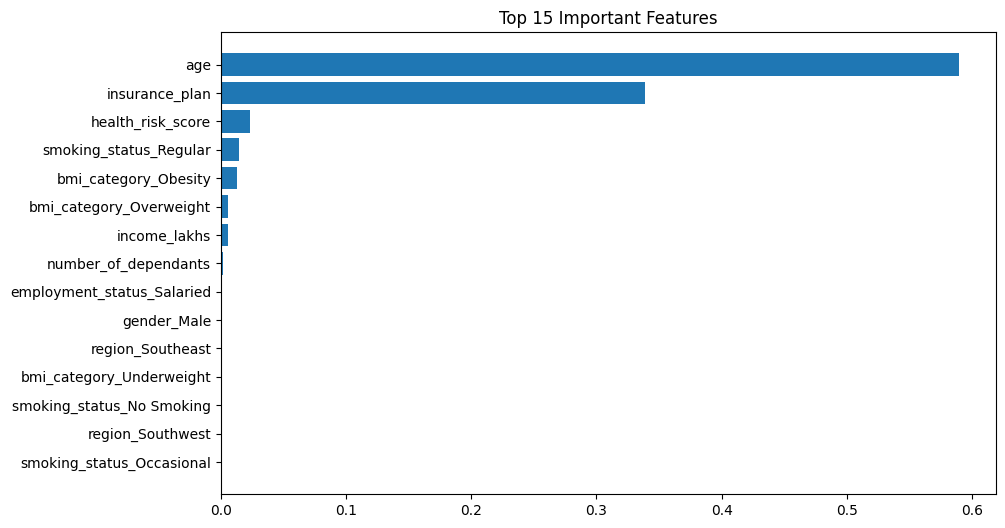

In [486]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:15],
    feature_importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.show()

In [487]:
# Linear Regression Coefficients
coef_df = pd.DataFrame({

    "Feature":X.columns,

    "Coefficient":lr.coef_

})

coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
3,insurance_plan,6232.815195
4,health_risk_score,5399.069626
10,bmi_category_Obesity,3381.841058
16,smoking_status_Regular,2163.847171
11,bmi_category_Overweight,1611.144943
15,smoking_status_Occasional,629.476265
14,smoking_status_Not Smoking,510.327906
19,employment_status_Self-Employed,370.988868
12,bmi_category_Underweight,332.972378
18,employment_status_Salaried,230.419578


Business_Insights

In [488]:
# Average Premium by Insurance Plan
plan = (
    df.groupby("insurance_plan")["annual_premium_amount"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plan


,insurance_plan,annual_premium_amount
0,Gold,26785.474257
1,Silver,17287.206929
2,Bronze,8779.348805


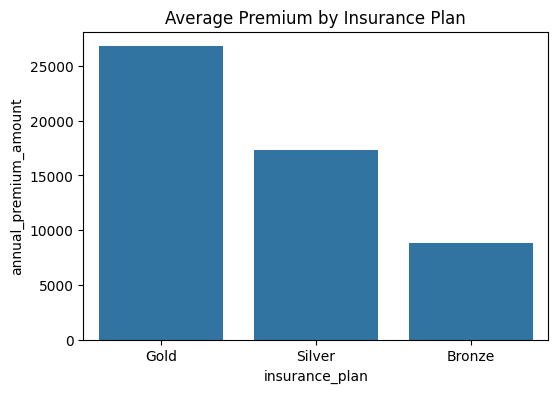

In [489]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=plan,
    x="insurance_plan",
    y="annual_premium_amount"
)

plt.title("Average Premium by Insurance Plan")

plt.show()

In [490]:
# Average Premium by Gender
gender = (
    df.groupby("gender")["annual_premium_amount"]
      .mean()
      .reset_index()
)

gender

,gender,annual_premium_amount
0,Female,15166.159096
1,Male,16257.036783


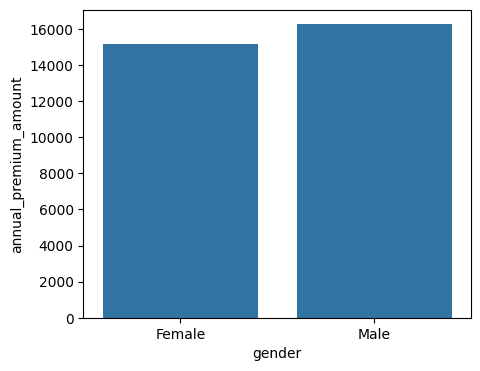

In [491]:
plt.figure(figsize=(5,4))

sns.barplot(
    data=gender,
    x="gender",
    y="annual_premium_amount"
)

plt.show()

In [492]:
# Smoking Impact
smoking = (
    df.groupby("smoking_status")["annual_premium_amount"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

smoking

,smoking_status,annual_premium_amount
0,Not Smoking,22931.750000
1,Regular,18240.654239
2,Occasional,17039.517316
3,Does Not Smoke,16832.166667
4,No Smoking,14023.735405
5,Smoking=0,12286.875000


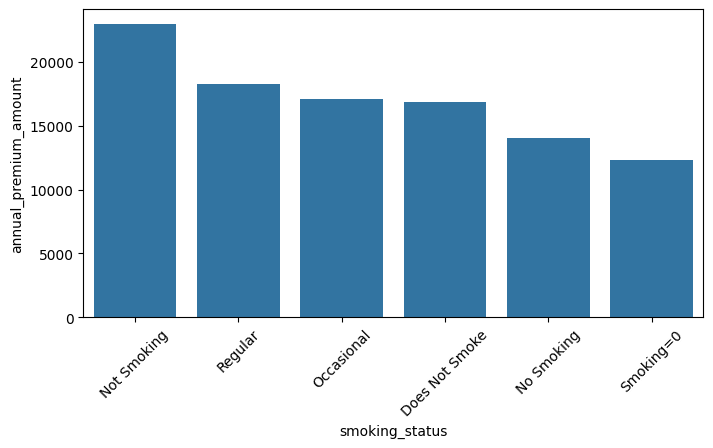

In [493]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=smoking,
    x="smoking_status",
    y="annual_premium_amount"
)

plt.xticks(rotation=45)

plt.show()

In [494]:
# Medical History Impact
medical = (
    df.groupby("medical_history")["annual_premium_amount"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

medical

,medical_history,annual_premium_amount
0,Heart disease,23341.965856
1,High blood pressure & Heart disease,20785.710134
2,Diabetes & Heart disease,20726.537212
3,High blood pressure,19736.894715
4,Thyroid,19718.014033
5,Diabetes,19707.901710
6,Diabetes & High blood pressure,19003.944546
7,Diabetes & Thyroid,18801.147085
8,No Disease,9987.144479


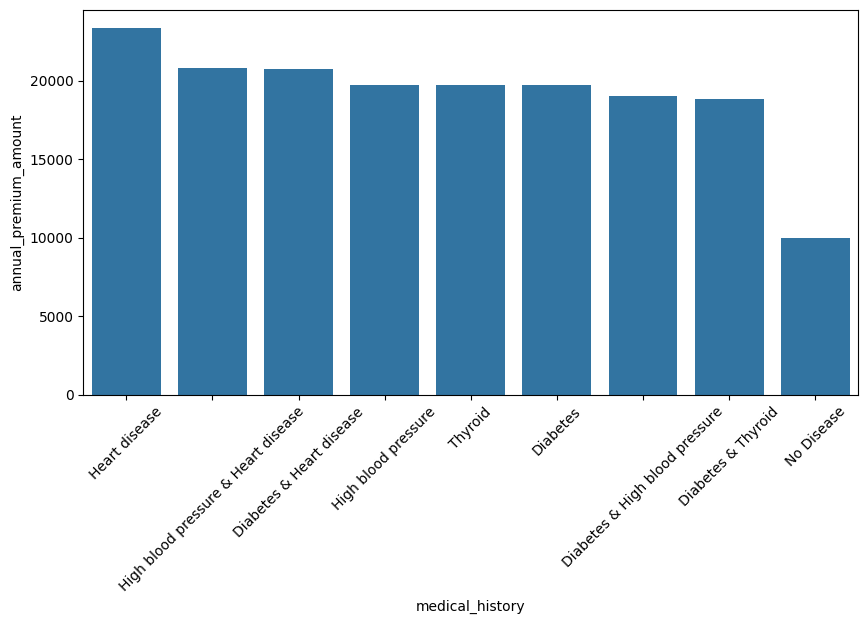

In [495]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=medical,
    x="medical_history",
    y="annual_premium_amount"
)

plt.xticks(rotation=45)

plt.show()

In [496]:
# Region Analysis
region = (
    df.groupby("region")["annual_premium_amount"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

region

,region,annual_premium_amount
0,Southeast,15860.139532
1,Northeast,15757.930389
2,Southwest,15716.866173
3,Northwest,15680.494017


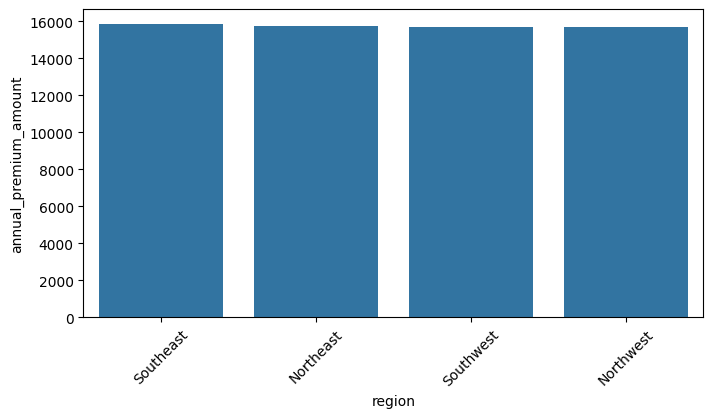

In [497]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=region,
    x="region",
    y="annual_premium_amount"
)

plt.xticks(rotation=45)

plt.show()

In [498]:
#Income Level Analysis
income = (
    df.groupby("income_level")["annual_premium_amount"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

income

,income_level,annual_premium_amount
0,> 40L,19835.339574
1,25L - 40L,16930.639151
2,10L - 25L,16811.023940
3,<10L,12872.446548


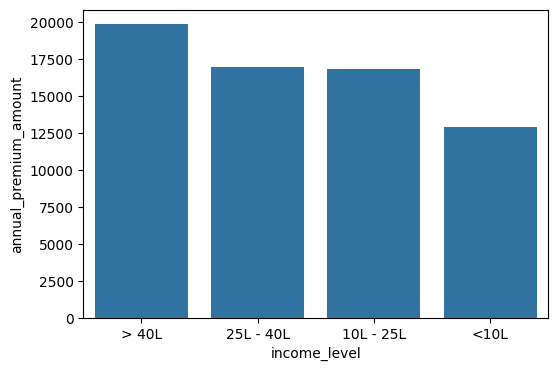

In [499]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=income,
    x="income_level",
    y="annual_premium_amount"
)

plt.show()

In [500]:
# BMI Category Analysis
bmi = (
    df.groupby("bmi_category")["annual_premium_amount"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

bmi

,bmi_category,annual_premium_amount
0,Obesity,20911.045620
1,Overweight,18637.686509
2,Normal,13664.056159
3,Underweight,13109.768834


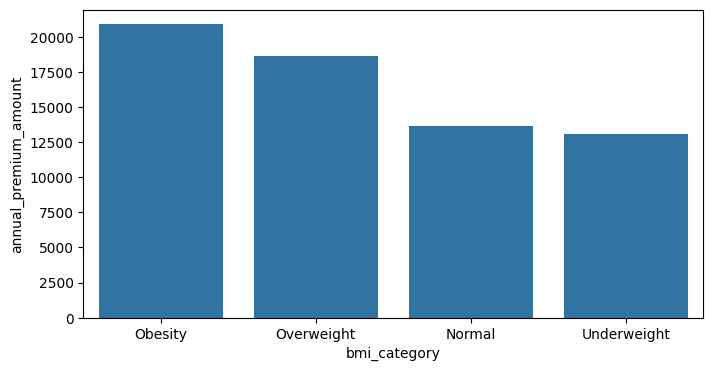

In [502]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=bmi,
    x="bmi_category",
    y="annual_premium_amount"
)

plt.show()

In [504]:
#Employment Status
employment = (
    df.groupby("employment_status")["annual_premium_amount"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

employment

,employment_status,annual_premium_amount
0,Self-Employed,19751.693010
1,Salaried,15711.836853
2,Freelancer,12324.672316


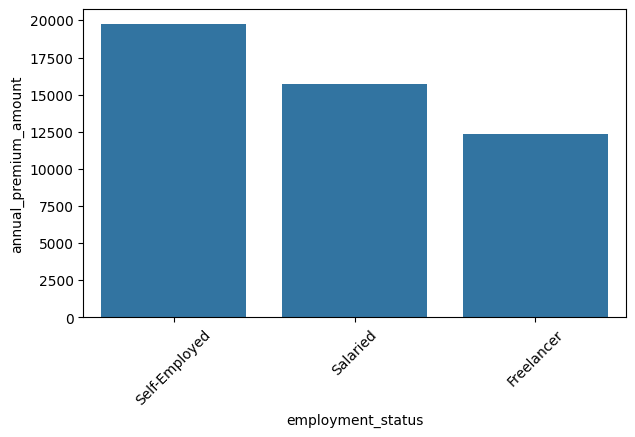

In [505]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=employment,
    x="employment_status",
    y="annual_premium_amount"
)

plt.xticks(rotation=45)

plt.show()

In [506]:
#Top 10 Highest Premium Customers
top10 = (
    df.nlargest(10, "annual_premium_amount")
)

top10

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
46124,71,Male,Northwest,Married,2,Obesity,Regular,Self-Employed,10L - 25L,24,Heart disease,Gold,43471
9920,63,Female,Southwest,Unmarried,0,Obesity,Regular,Self-Employed,10L - 25L,23,Heart disease,Gold,43119
22653,72,Female,Southwest,Married,1,Obesity,Regular,Self-Employed,10L - 25L,18,Diabetes & High blood pressure,Gold,41848
19922,65,Male,Northwest,Married,1,Overweight,Regular,Self-Employed,10L - 25L,20,Heart disease,Gold,41658
16457,69,Male,Northeast,Married,1,Overweight,Regular,Self-Employed,25L - 40L,25,Heart disease,Gold,41556
29627,67,Male,Southeast,Married,1,Overweight,Regular,Self-Employed,> 40L,57,Heart disease,Gold,41461
14143,69,Female,Southwest,Married,2,Overweight,Regular,Self-Employed,> 40L,44,Heart disease,Gold,41317
31513,63,Male,Northwest,Unmarried,0,Obesity,No Smoking,Self-Employed,10L - 25L,21,Heart disease,Gold,40478
29540,68,Male,Southwest,Married,1,Underweight,Regular,Self-Employed,10L - 25L,10,Heart disease,Gold,40138
6392,71,Male,Southeast,Married,1,Underweight,Regular,Salaried,10L - 25L,17,High blood pressure & Heart disease,Gold,40063


In [507]:
# Correlation with Premium
corr = (
    df_fe.corr(numeric_only=True)
    ["annual_premium_amount"]
    .sort_values(ascending=False)
)

corr

,annual_premium_amount
annual_premium_amount,1.000000
insurance_plan,0.834148
age,0.767569
health_risk_score,0.470789
number_of_dependants,0.414691
income_lakhs,0.243058


Business Insights

• Customers with Heart Disease and Diabetes pay the highest premiums.

• Smokers have significantly higher premiums than non-smokers.

• Higher income customers generally purchase higher-value insurance plans.

• Health Risk Score is one of the strongest drivers of premium amount.

• Premiums increase with age, indicating age is a key pricing factor.

• Gold Insurance Plan customers contribute the highest average premium.

Recommendations

• Design targeted wellness programs for high-risk customers.

• Offer preventive healthcare discounts to reduce future claims.

• Develop customized premium packages for different risk groups.

• Use Health Risk Score as an important feature in premium pricing.